# Postprocessing of statistics


### First we read the statistics fields
The idea here is that we have already accumulated certain statistics using the statistics toolbox in `neko`.

We only really care about mean fields right now, but for the full documentation of the statistics output file see:

https://neko.cfd/docs/develop/df/d8f/statistics-guide.html

If everything goes well with Tim's script we should have a `fluid_stats0/` folder floating around somewhere.


### PyNekTools

All information about PyNekTools can be found:

https://github.com/ExtremeFLOW/pyNekTools

If you don't have access you can contact Bertie, but if you have access to `neko` you should have access to this.

In [1]:
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'



def load_stats_file(file_name, fld_number):

    # Import required modules
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    #import os
    #os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    

    # set mesh and fld
    
    msh = Mesh(comm, create_connectivity=True)
    fld = FieldRegistry(comm)
    
    # remember the mesh is only stored in the first one!
    # here we're just getting the mesh
    pynekread(file_name+'.f00000', comm, data_dtype=np.double, msh=msh)
    
    # TODO
    # Right now I'm just playing around with one, but ultimately we will take an "average of the averages"
    pynekread(file_name + '.f' + "{:05d}".format(fld_number), comm, data_dtype=np.double, fld=fld)

    return msh, fld

### Plot the 2D velocity field
This isn't necessary, I was just checking that it works. These tools are so nice!!

In [18]:
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
import matplotlib.pyplot as plt
import numpy as np
from pynektools.datatypes.field import FieldRegistry


# path locations
results_path = "../../../results/only_stats/brinkman_parameters/cases/"
brinkman_path = "brinkman_mesh_2_re_200_chi_1000_radius_0-01/"
meshed_path = "meshed_mesh_4_re_200/"
stats_file = "fluid_stats0"
# stats_file = "field0"
meshed = {}
IBM = {}
meshed["name"] = 'meshed'
IBM["name"] = 'IBM'


# IBM
file_name = results_path + brinkman_path + stats_file + '/' + stats_file
IBM["mesh"], IBM["fld"] = load_stats_file(file_name, 2)

# Meshed
file_name = results_path + meshed_path + stats_file + '/' + stats_file
meshed["mesh"], meshed["fld"] = load_stats_file(file_name, 2)

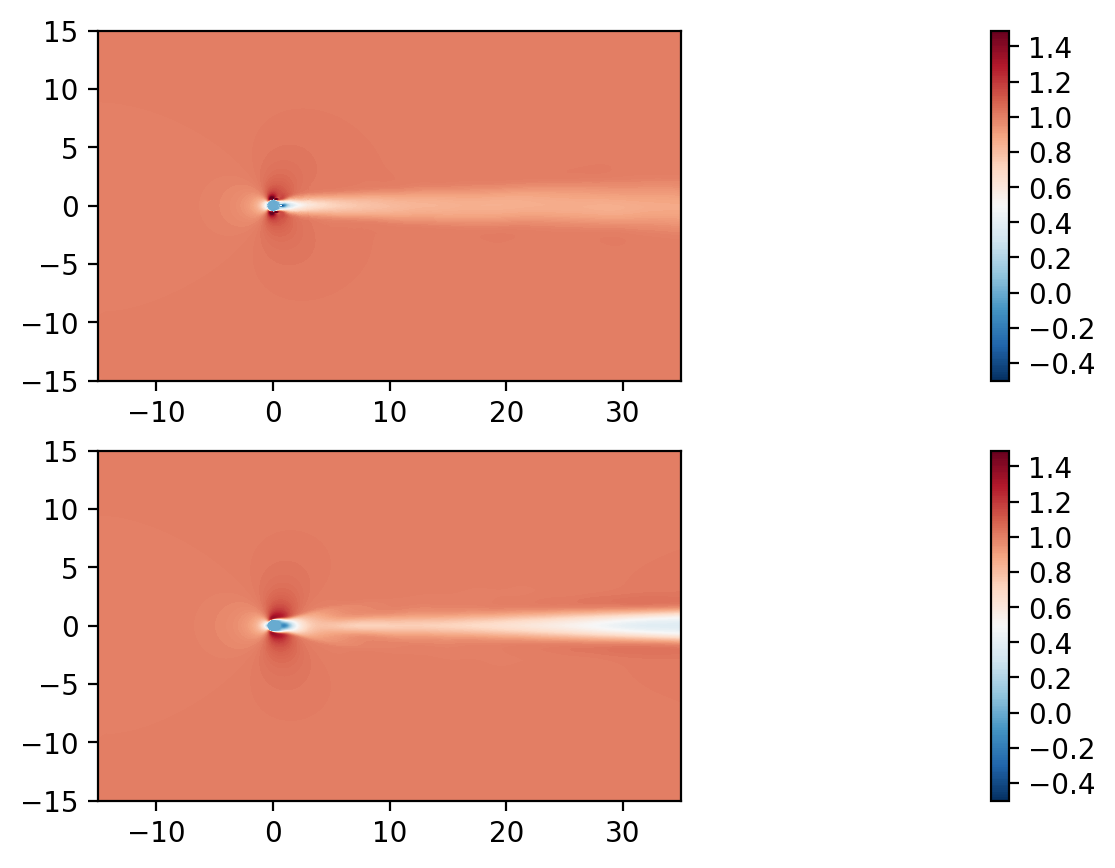

In [20]:
fig, ax = plt.subplots(2,1, figsize=(40, 5), dpi = 200)
c = ax[0].tricontourf(IBM["mesh"].x.flatten(), IBM["mesh"].y.flatten() ,IBM["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
fig.colorbar(c)
ax[0].set_aspect('equal')
c = ax[1].tricontourf(meshed["mesh"].x.flatten(), meshed["mesh"].y.flatten() ,meshed["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
fig.colorbar(c)
ax[1].set_aspect('equal')
plt.show()

## Wake Deficit

We should inspect the wake (of the averaged fields) and some downstream locations.
Right now I'm just plotting them all on the same plot. But I guess what would be more useful is to plot different cases

In [21]:
def generate_wake_lines(msh, fld, wake_positions, y_lims, n_pts):
    # Import required modules
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # set up the probe locations
    if comm.Get_rank() == 0 :
        # Wake line
        y_1d = pcs.generate_1d_arrays(y_lims, n_pts, mode="equal")
        x_1d = wake_positions
        z_1d = [0.5]
        x, y, z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')
        # Write the points for future use
        xyz = interp_utils.transform_from_array_to_list(len(wake_positions),n_pts,1,[x, y, z])
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    # here we actually probe
    probes.interpolate_from_field_list(0, [fld.registry['u']], comm, write_data=False)
    # package them nicely
    int_fields = interp_utils.transform_from_list_to_array(len(wake_positions),n_pts,1,probes.interpolated_fields)
    wake_u = np.copy(int_fields[1])
    # I think we only really need u...
    return xyz, wake_u

### plotting wake deficit

Now we can plot the wake lines in certain locations.

In [27]:
# All wake size/resolution
# Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'

y_lims = [-15, 15]
n_pts = 300
wake_positions = [10, 15, 20]
U_lims = [0.5, 1.2]

IBM["wake_positions"] = wake_positions
meshed["wake_positions"] = wake_positions
IBM["wake_xyz"], IBM["wake_u"]  = generate_wake_lines(IBM["mesh"], IBM["fld"], IBM["wake_positions"], y_lims, n_pts)
meshed["wake_xyz"], meshed["wake_u"] = generate_wake_lines(meshed["mesh"], meshed["fld"], meshed["wake_positions"], y_lims, n_pts)

case_list = [IBM, meshed]

In [32]:
def plot_wake_lines(case_list):
    # gotta assume they're all the same
    wake_positions = case_list[0]["wake_positions"]
    fig, ax = plt.subplots(1, len(wake_positions), figsize=(10, 5), dpi = 200)
    for i in range(len(wake_positions)):
        for j in range(len(case_list)):
            case = case_list[j]
            wake_index = np.where(case["wake_xyz"][:,0] == wake_positions[i])
            ax[i].plot(case["wake_u"][i,:].flatten(), case["wake_xyz"][wake_index, 1].flatten(), label=case["name"])
        ax[i].set_title('Wake at x ='+str(wake_positions[i]))
        ax[i].set_xlim(U_lims)
        ax[i].set_ylim(y_lims)
    ax[len(wake_positions)-1].legend()
    plt.show()

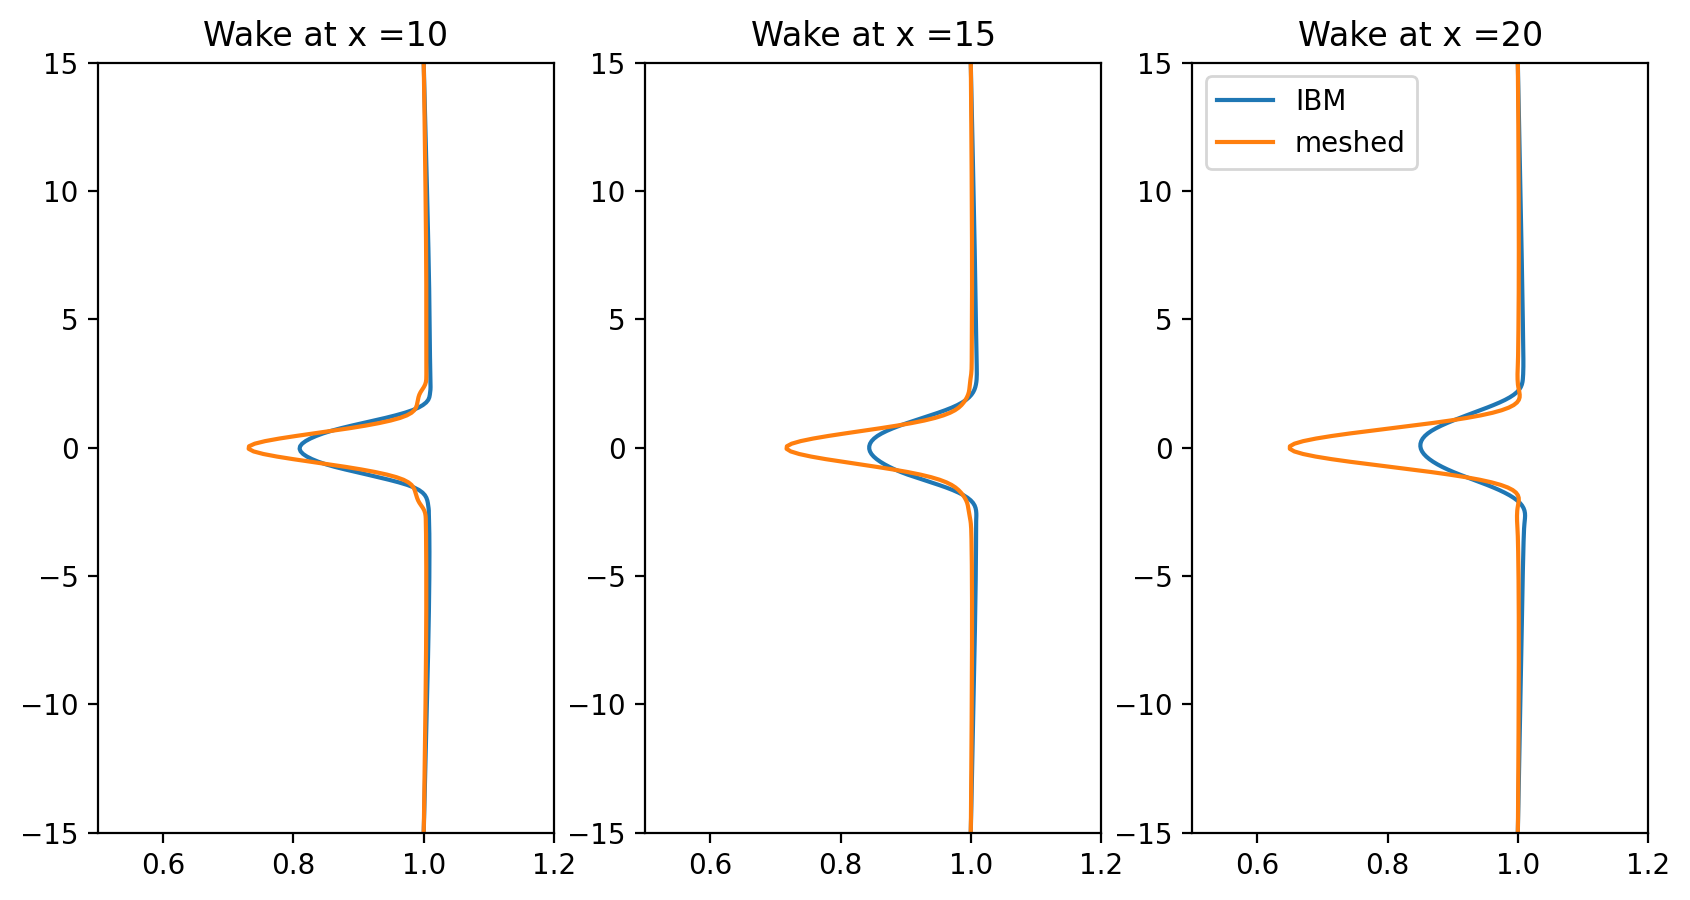

In [33]:
plot_wake_lines(case_list)

# Avereage lift and drag

If this was a surface, we would be integrating the traction $\mathbf{\sigma} \mathbf{n}$ on the boundary, ie,

$\mathbf{F} = \int_{\partial \Omega} \mathbf{\sigma} \mathbf{n} \, dS,$

where $\mathbf{n}$ is the normal vector and $\mathbf{\sigma}$ is the stress tensor, which, for a Newtonian fluid, takes the form $\mathbf{\sigma} = \mu \left( \nabla \mathbf{u} + (\nabla \mathbf{u})^T\right) - \mathbf{I}p$.

Of course this requires $\nabla \mathbf{u}$, so thank god we can rely on Bertie's toolbox to compute gradients in post.

In [41]:
def calculate_forces(msh, fld, ring_radii, n_points, Re):
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry

    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    dudx = coef.dudxyz(fld.registry['u'], coef.drdx, coef.dsdx, coef.dtdx)
    dudy = coef.dudxyz(fld.registry['u'], coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(fld.registry['v'], coef.drdx, coef.dsdx, coef.dtdx)
    dvdy = coef.dudxyz(fld.registry['v'], coef.drdy, coef.dsdy, coef.dtdx)

    # set up probes
    if comm.Get_rank() == 0 :
    
        # Generate the 1D mesh
        r_1d = np.array(ring_radii)
        th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")
        z_1d = np.array([0.5])
    
        # Generate a 3D mesh
        r, th, z = np.meshgrid(r_1d, th_1d, z_1d, indexing='ij')
        x = r*np.cos(th)
        y = r*np.sin(th)
    
        # Array the points as a list of probes
        xyz = interp_utils.transform_from_array_to_list(len(ring_radii),n_points,1,[x, y, z])
    
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    ring_probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    
    # here we actually probe
    ring_probes.interpolate_from_field_list(0, [dudx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dudy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [fld.registry['p']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    p = np.copy(int_fields[1])
    
    f_x_visc = np.zeros((len(ring_radii), n_points))
    f_y_visc = np.zeros((len(ring_radii), n_points))
    f_x_p    = np.zeros((len(ring_radii), n_points))
    f_y_p    = np.zeros((len(ring_radii), n_points))
    f_x_tot  = np.zeros((len(ring_radii), n_points))
    f_y_tot  = np.zeros((len(ring_radii), n_points))
    
    f_x_visc_int = np.zeros((len(ring_radii)))
    f_y_visc_int = np.zeros((len(ring_radii)))
    f_x_p_int    = np.zeros((len(ring_radii)))
    f_y_p_int    = np.zeros((len(ring_radii)))
    f_x_tot_int  = np.zeros((len(ring_radii)))
    f_y_tot_int  = np.zeros((len(ring_radii)))
    
    for i in range(len(ring_radii)):
        for j in range(n_points):
            # viscous
            f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + \
                             (dudy[i,j] + dvdx[i,j]) * np.sin(th_1d[j]))/Re
            f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + \
                              dvdy[i,j] * 2          * np.sin(th_1d[j]))/Re
            
            #pressure
            f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
            f_y_p[i,j] = -p[i,j] * np.sin(th_1d[j])

            # total
            f_x_tot[i,j] = f_x_visc[i,j] + f_x_p[i,j]
            f_y_tot[i,j] = f_y_visc[i,j] + f_y_p[i,j]

    # Here we integrate them around to get a single number
    for i in range(len(ring_radii)):
        ri1 = (n_points)*i
        ri2 = (n_points )*(i+1)
        dS = (2 * np.pi * ring_radii[i]) / n_points
        
        f_x_visc_int[i] = np.sum(f_x_visc[i,:]) * dS
        f_y_visc_int[i] = np.sum(f_y_visc[i,:]) * dS
        f_x_p_int[i]    = np.sum(f_x_p[i,:]) * dS
        f_y_p_int[i]    = np.sum(f_y_p[i,:]) * dS
        
        f_x_tot_int[i] = f_x_visc_int[i] + f_x_p_int[i]
        f_y_tot_int[i] = f_y_visc_int[i] + f_y_p_int[i]

        force_measure = {}
        force_measure["fx_tot"] = f_x_tot
        force_measure["fx_p"] = f_x_p
        force_measure["fx_visc"] = f_x_visc
        force_measure["fy_tot"] = f_y_tot
        force_measure["fy_p"] = f_y_p
        force_measure["fy_visc"] = f_y_visc
        force_measure["fx_tot_int"] = f_x_tot_int
        force_measure["fx_p_int"] = f_x_p_int
        force_measure["fx_visc_int"] = f_x_visc_int
        force_measure["fy_tot_int"] = f_y_tot_int
        force_measure["fy_p_int"] = f_y_p_int
        force_measure["fy_visc_int"] = f_y_visc_int
        force_measure["ring"] = ring_radii

    return force_measure
    

Since we don't have a surface, 

If we take a ring around the cylinder we can probe and integrate the forces around the cylinder.

In [42]:
ring_radii = [0.50, 0.501, 0.502, 0.504, 0.508, 0.516, 0.532]
n_points = 360
Re = 200

IBM["stats_forces"] = calculate_forces(brinkman_msh, brinkman_fld, ring_radii, n_points, Re)
meshed["stats_forces"] = calculate_forces(meshed_msh, meshed_fld, ring_radii, n_points, Re)

/tmp/user/12792/ipykernel_1803260/726090971.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + \
/tmp/user/12792/ipykernel_1803260/726090971.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + \
/tmp/user/12792/ipykernel_1803260/726090971.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
/tmp/user

In [59]:
def plot_ring(case_list, rings_plot):
    th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")

    fig, ax = plt.subplots(len(rings_plot),1, figsize=(10, 5*len(rings_plot)), dpi = 200)

    # lets just look at 2
    for i in range(len(rings_plot)):
        for j in range(len(case_list)):
            case = case_list[j]
            ring_index = np.where(np.array(case["stats_forces"]["ring"]) == np.array(rings_plot[i]))
            F_tot = np.sqrt(case["stats_forces"]["fx_tot"][ring_index,:]**2 + case["stats_forces"]["fy_tot"][ring_index,:]**2)
            ax[i].plot(th_1d/np.pi*180, F_tot[ring_index,:].flatten, label=case["name"])
    ax[i].set_title('Ring at r ='+str(ring_radii[i]))
    ax[i].set_xlabel(r'$\theta$')
    ax[i].set_ylabel(r'$|F|$')
    ax[0].legend()
    plt.show()

In [56]:
F_tot = np.sqrt(IBM["stats_forces"]["fx_tot"][1,:]**2 + IBM["stats_forces"]["fy_tot"][1,:]**2)
print(F_tot)

[0.97619523 0.94073718 0.94586307 0.96206041 0.97532707 0.98167351
 0.98249195 0.98098486 0.97972008 0.97928808 0.97796179 0.97219161
 0.95770059 0.93088155 0.89014957 0.83688934 0.77567937 0.7135957
 0.6586054  0.6173478  0.59292936 0.58364778 0.5836893  0.58664951
 0.57171635 0.54777792 0.52235273 0.49049295 0.45407088 0.41846437
 0.3891023  0.36869442 0.3558387  0.34542648 0.33086243 0.3076284
 0.27722633 0.24421559 0.21071741 0.18398141 0.16849965 0.16235508
 0.16024757 0.15686447 0.14922721 0.13745825 0.12416847 0.11310571
 0.10773547 0.110126   0.12009287 0.13424153 0.14453801 0.15391882
 0.14731968 0.15414775 0.13663457 0.08932572 0.03122034 0.01571622
 0.01480956 0.03707069 0.12896686 0.23307384 0.31022328 0.32497979
 0.26264821 0.17836185 0.0991564  0.03330041 0.02277129 0.05723868
 0.16729275 0.32790208 0.50383095 0.66123003 0.77528273 0.83479378
 0.84251813 0.81204192 0.76266968 0.71384388 0.68037041 0.66933045
 0.67917117 0.70115924 0.72316737 0.73566302 0.73977952 0.757428

ValueError: x and y must have same first dimension, but have shapes (360,) and (1, 1, 1, 360)

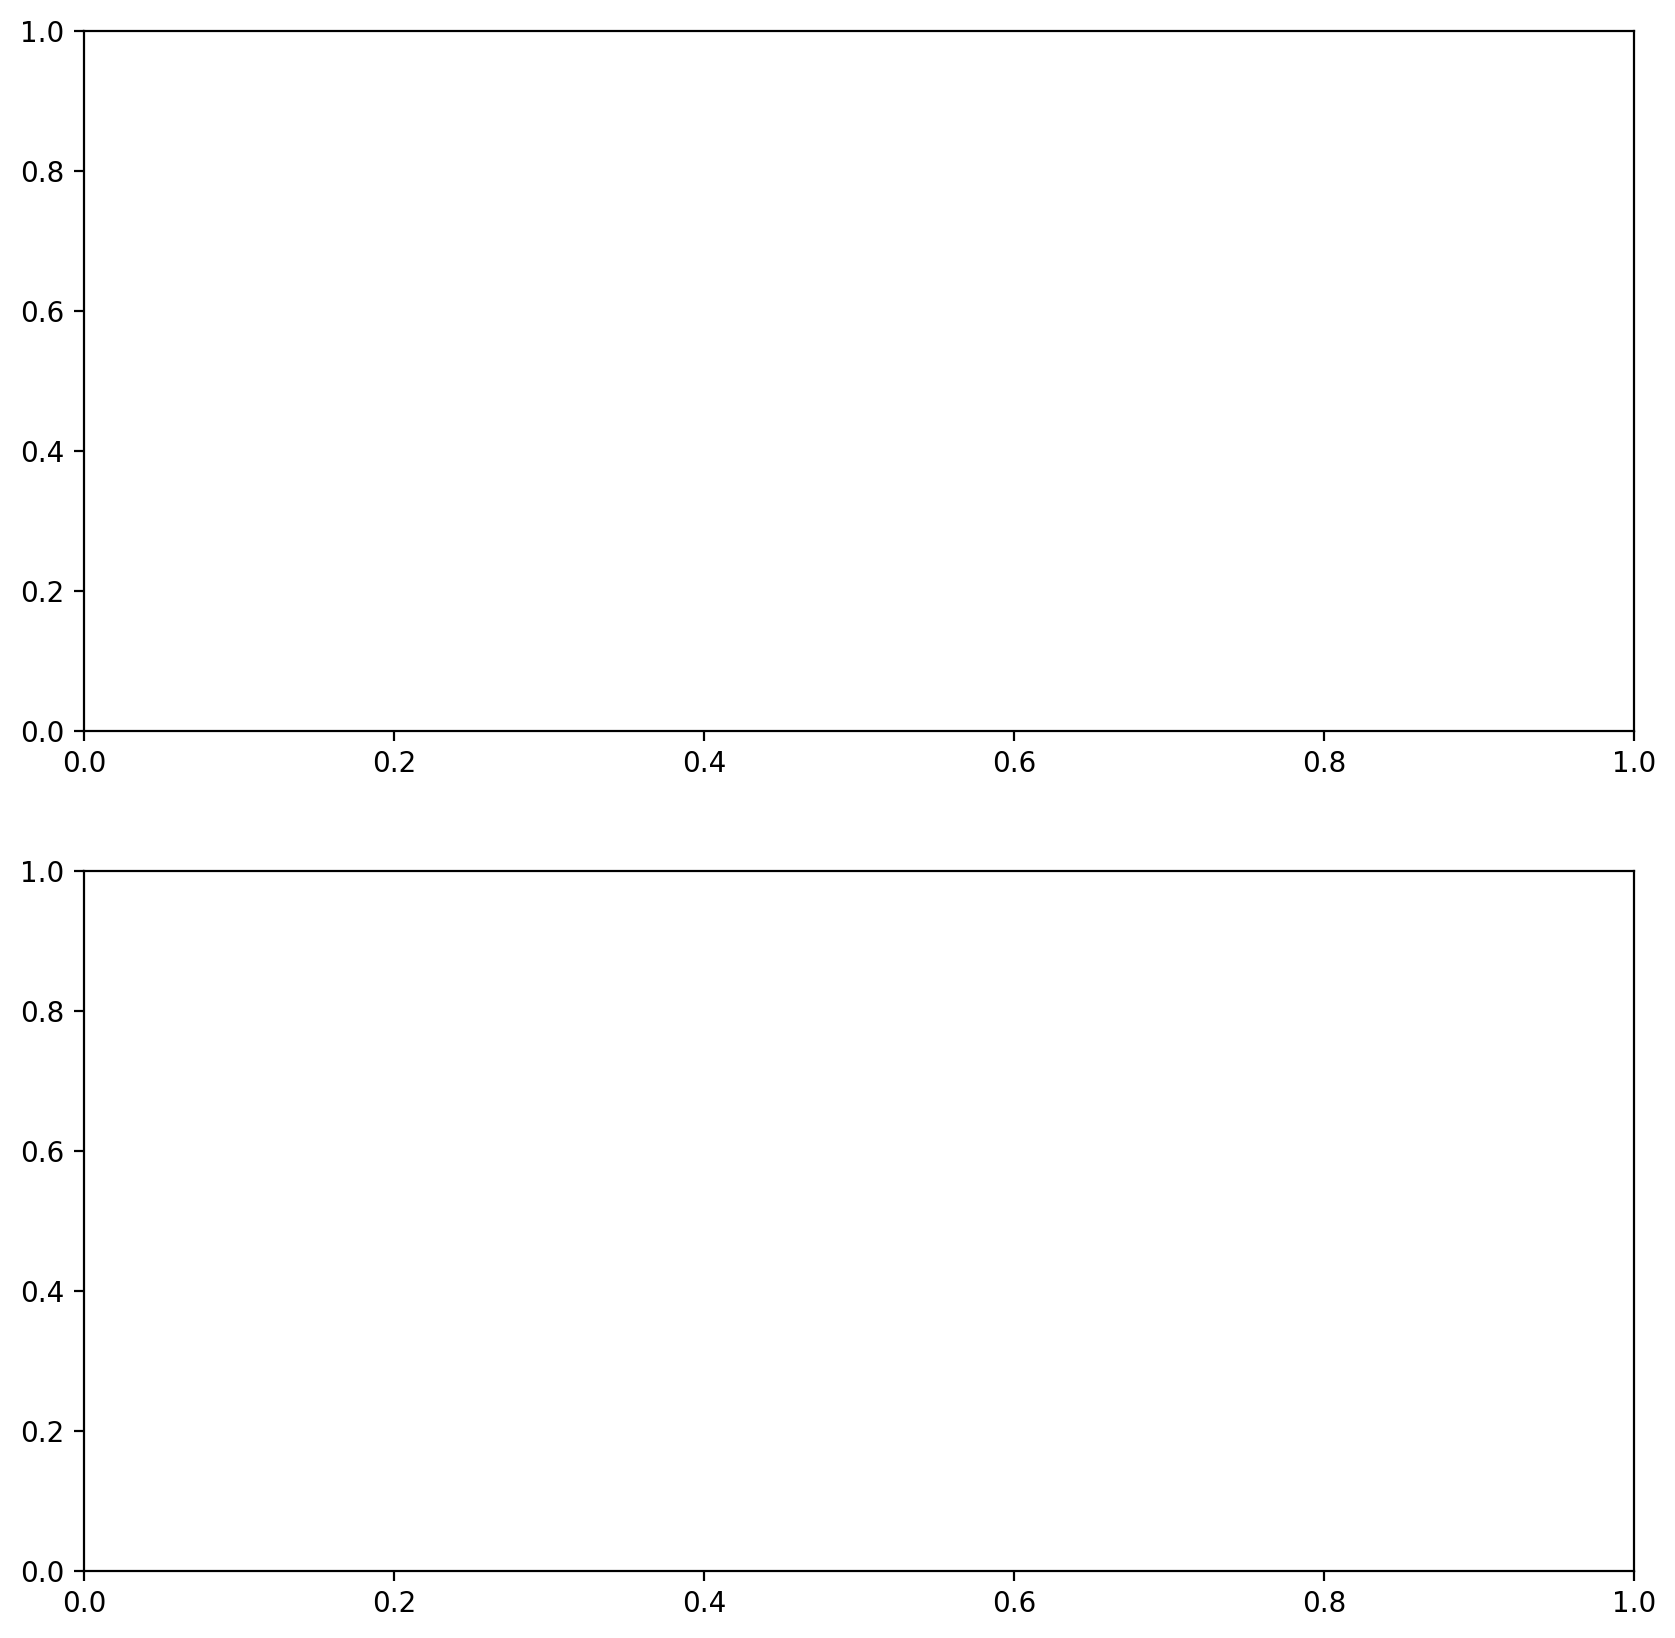

In [58]:
case_list = [IBM, meshed]
plot_ring(case_list, [0.50, 0.532])

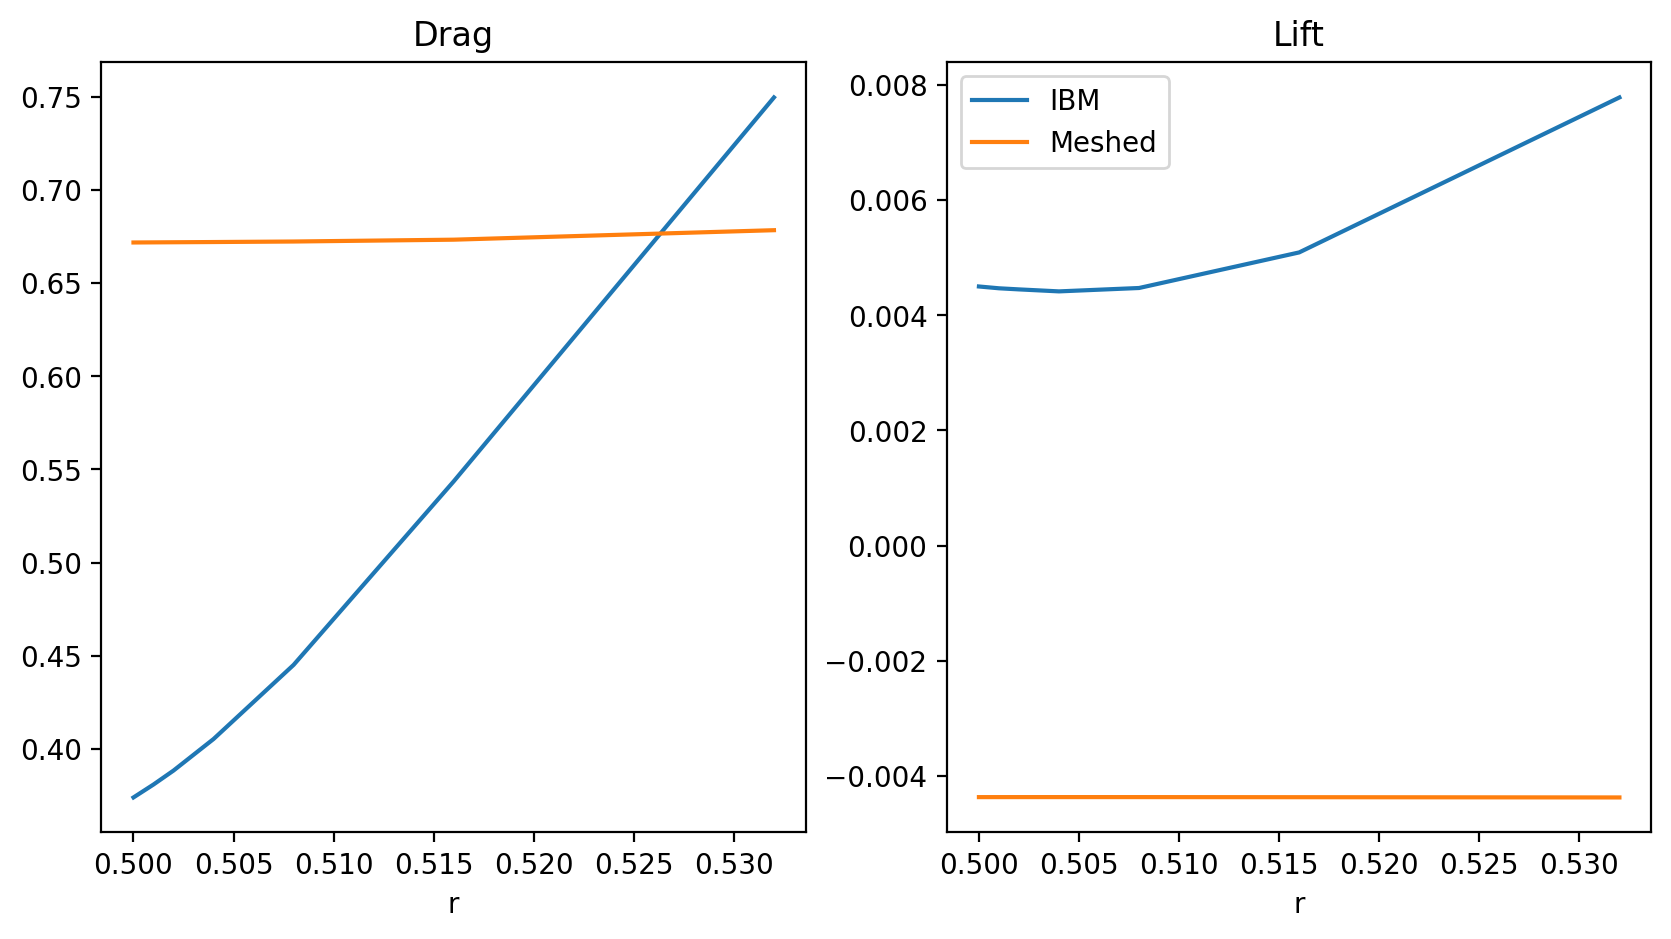

In [10]:
# Maybe look at how lift and drag changes with the circle we take:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)
ax[0].plot(ring_radii, brinkman_f_x_tot_int)
ax[0].plot(ring_radii, meshed_f_x_tot_int)
ax[0].set_title('Drag')
ax[0].set_xlabel('r')

ax[1].plot(ring_radii, brinkman_f_y_tot_int, label='IBM')
ax[1].plot(ring_radii, meshed_f_y_tot_int, label='Meshed')
ax[1].set_title('Lift')
ax[1].set_xlabel('r')
ax[1].legend()
plt.show()

# Vorticity

For post processing nice videos it's alway nice to show vorticity instead of velocity.

Again, Berties tools allow us compute vorticity in aposteri.

In [11]:
def compute_vorticity(path_name, file_name):

    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    
    # Readers
    from pynektools.io.ppymech.neksuite import preadnek, pynekread
    
    # Writers
    from pynektools.io.ppymech.neksuite import pwritenek, pynekwrite
    
    from pynektools.postprocessing.file_indexing import index_files_from_folder
    
    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'


    # ------------------------------------------------------------------------------------
    # just do the first one for the mesh
    # set mesh and fld
    msh = Mesh(comm, create_connectivity=True)
    fld = FieldRegistry(comm)
    fld_out = FieldRegistry(comm)
    
    # remember the mesh is only stored in the first one!
    # here we're just getting the mesh
    pynekread(path_name + file_name +'.f00000', comm, data_dtype=np.single, msh=msh, fld=fld)
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    u = fld.fields['vel'][0]
    v = fld.fields['vel'][1]
    dudy = coef.dudxyz(u, coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(v, coef.drdx, coef.dsdx, coef.dtdx)
    
    # compute vorticity
    vort = dvdx - dudy

    # TODO
    # Maybe we wan't a gsop here if it looks ugly!
    
    # add to the registry of output
    fld_out.t = fld.t
    fld_out.fields['scal'].append(vort)
    fld_out.update_vars()
    
    # write it out
    file_name_out = path_name + 'vort0.f00000'
    pynekwrite(file_name_out, comm, msh=msh, fld=fld_out, write_mesh=True, wdsz=4, istep = 0)
    
    # ------------------------------------------------------------------------------------
    # now we can do all the remain files
    i = 1
    file_exists = True
    while file_exists:
        f_in = path_name + file_name  + '.f' + "{:05d}".format(i)
        file_exists = os.path.isfile(f_in)
        if not file_exists:
            break
    
        # new field
        fld = FieldRegistry(comm)
        fld_out = FieldRegistry(comm)
    
        # now we don't need the mesh or coef
        pynekread(f_in, comm, data_dtype=np.single, fld=fld)
    
        u = fld.fields['vel'][0]
        v = fld.fields['vel'][1]
        dudy = coef.dudxyz(u, coef.drdy, coef.dsdy, coef.dtdx)
        dvdx = coef.dudxyz(v, coef.drdx, coef.dsdx, coef.dtdx)
        
        # compute vorticity
        vort = dvdx - dudy
    
        # TODO
        # Maybe we wan't a gsop here if it looks ugly!
    
        # add to registry
        fld_out.t = fld.t
        fld_out.fields['scal'].append(vort)
        fld_out.update_vars()
        
        # write it out
        file_name_out = path_name + 'vort0'  + '.f' + "{:05d}".format(i)
        pynekwrite(file_name_out, comm, msh=msh, fld=fld_out, write_mesh=False, wdsz=4, istep = i)
    
        
        print(f_in)
        i += 1



### Visulization

I would envision the actual post processing will be done in `visit` or `paraview`, but here we'll just take a little looking in this notebook.


In [12]:
# compute the vorticity
compute_vorticity(results_path + brinkman_path + 'field0/', 'field0')
compute_vorticity(results_path + meshed_path + 'field0/', 'field0')

FileNotFoundError: [Errno 2] No such file or directory: '../../../results/only_stats/brinkman_parameters/cases/brinkman_mesh_2_re_200_chi_1000_radius_0-01/field0/field0.f00000'

In [ ]:
# load in the vorticty and plot
vort_brinkman_msh, vort_brinkman_fld = load_stats_file(results_path + brinkman_path + 'field0/vort0', 1)
vort_meshed_msh, vort_meshed_fld = load_stats_file(results_path + meshed_path + 'field0/vort0', 1)

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(40, 5), dpi = 200)
c = ax[0].tricontourf(brinkman_msh.x.flatten(), brinkman_msh.y.flatten() ,vort_brinkman_fld.fields['scal'][0].flatten(), levels=np.arange(start=-10, stop=10, step=0.1), cmap="RdBu_r")
fig.colorbar(c)
ax[0].set_aspect('equal')
c = ax[1].tricontourf(meshed_msh.x.flatten(), meshed_msh.y.flatten() ,vort_meshed_fld.fields['scal'][0].flatten(), levels=np.arange(start=-10, stop=10, step=0.1), cmap="RdBu_r")
fig.colorbar(c)
ax[1].set_aspect('equal')
plt.show()